# Model Training & Evaluation
## Personalized Healthcare & Medicine Recommendation System

This notebook documents the modeling process behind the three models in the system:

| Model | Task | Data |
|-------|------|------|
| **1. Disease predictor** | 41-class classification | 4,920 records × 132 binary symptoms |
| **2. Risk screener** | Positive/Negative outcome | symptoms + vitals (age, gender, BP, cholesterol) |
| **3. Review sentiment (NLP)** | Positive/Negative review | 215K drugs.com patient reviews |

For each: candidate comparison → best-model selection → held-out evaluation → error analysis.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent / 'src'))
sns.set_theme(style='whitegrid')

from preprocess import load_disease_symptoms, load_patient_profile
MODELS = Path.cwd().parent / 'models'

---
## 1. Disease Prediction Model
### 1.1 Candidate comparison (5-fold stratified CV)

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder

X, y = load_disease_symptoms()
le = LabelEncoder(); y_enc = le.fit_transform(y)
X_tr, X_te, y_tr, y_te = train_test_split(X.values, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

candidates = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'NaiveBayes': MultinomialNB(),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, eval_metric='mlogloss', random_state=42, n_jobs=-1),
}
cv = StratifiedKFold(5, shuffle=True, random_state=42)
rows = []
for name, model in candidates.items():
    s = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy')
    rows.append({'model': name, 'cv_mean': s.mean(), 'cv_std': s.std()})
cmp_df = pd.DataFrame(rows).sort_values('cv_mean', ascending=False)
cmp_df.style.format({'cv_mean': '{:.4f}', 'cv_std': '{:.4f}'})

,model,cv_mean,cv_std
0,RandomForest,1.0000,0.0000
1,SVM (RBF),1.0000,0.0000
2,NaiveBayes,1.0000,0.0000
3,XGBoost,0.9987,0.0025


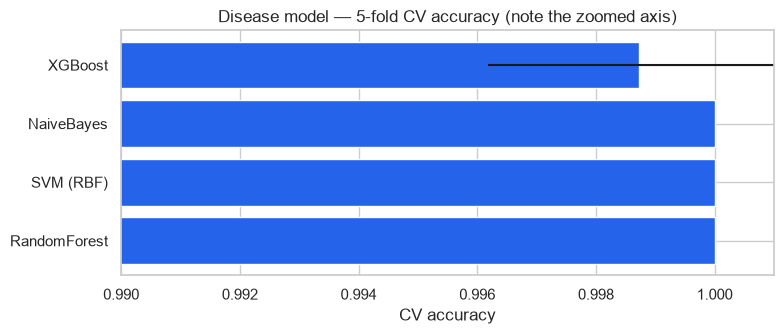

All models are at/near 100% — the dataset is cleanly separable (each disease has a distinct symptom signature).


In [3]:
plt.figure(figsize=(8, 3.5))
plt.barh(cmp_df['model'], cmp_df['cv_mean'], xerr=cmp_df['cv_std'], color='#2563eb')
plt.xlim(0.99, 1.001)
plt.title('Disease model — 5-fold CV accuracy (note the zoomed axis)')
plt.xlabel('CV accuracy')
plt.tight_layout(); plt.show()
print('All models are at/near 100% — the dataset is cleanly separable (each disease has a distinct symptom signature).')

### 1.2 Held-out evaluation — RandomForest (selected)

Held-out test accuracy: 1.0000  (984 samples, 41 classes)


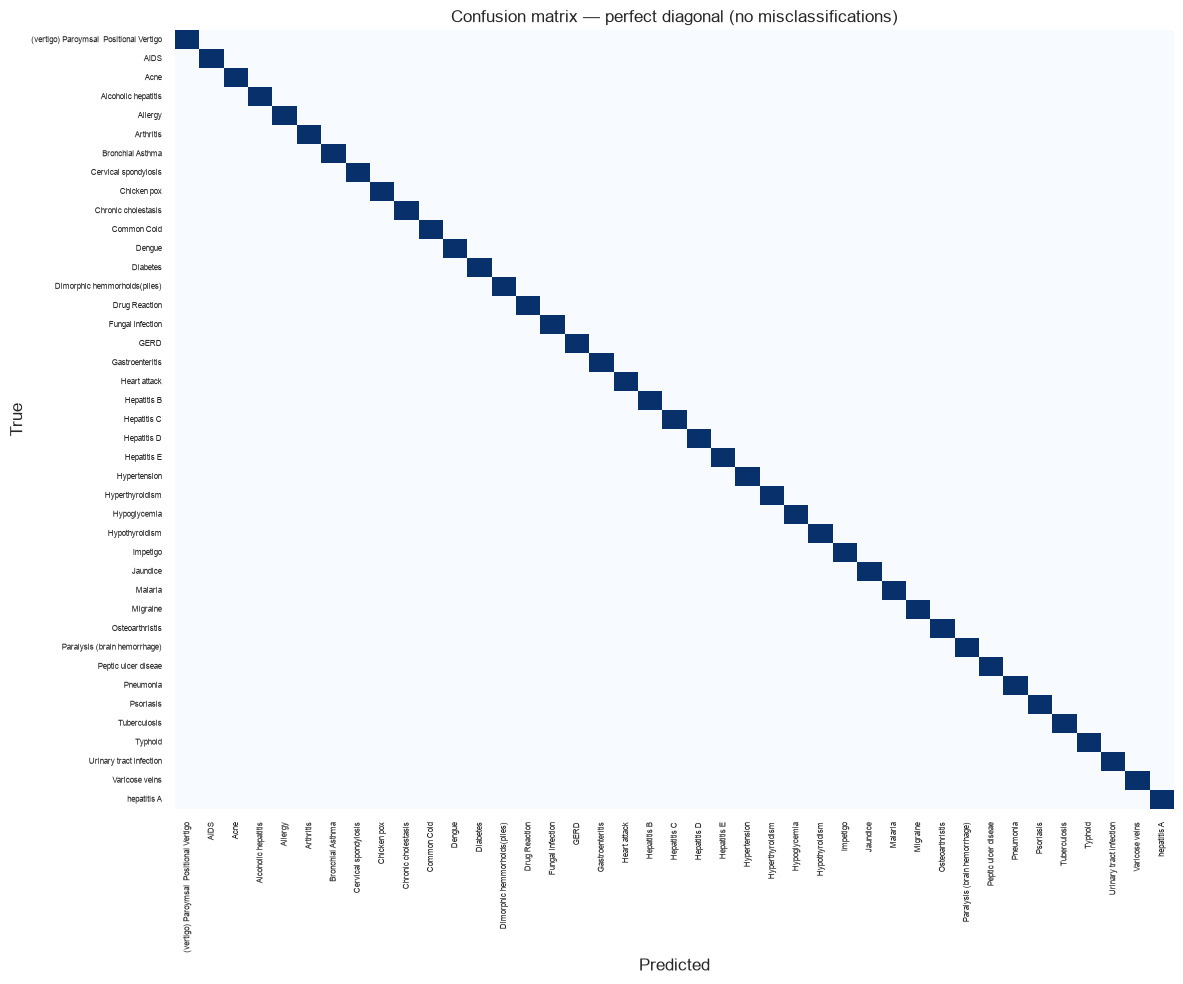

In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix

best = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
pred = best.predict(X_te)
print(f'Held-out test accuracy: {accuracy_score(y_te, pred):.4f}  ({len(y_te)} samples, 41 classes)')

cm = confusion_matrix(y_te, pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues', cbar=False, xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix — perfect diagonal (no misclassifications)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(fontsize=6, rotation=90); plt.yticks(fontsize=6)
plt.tight_layout(); plt.show()

### 1.3 Which symptoms matter most?

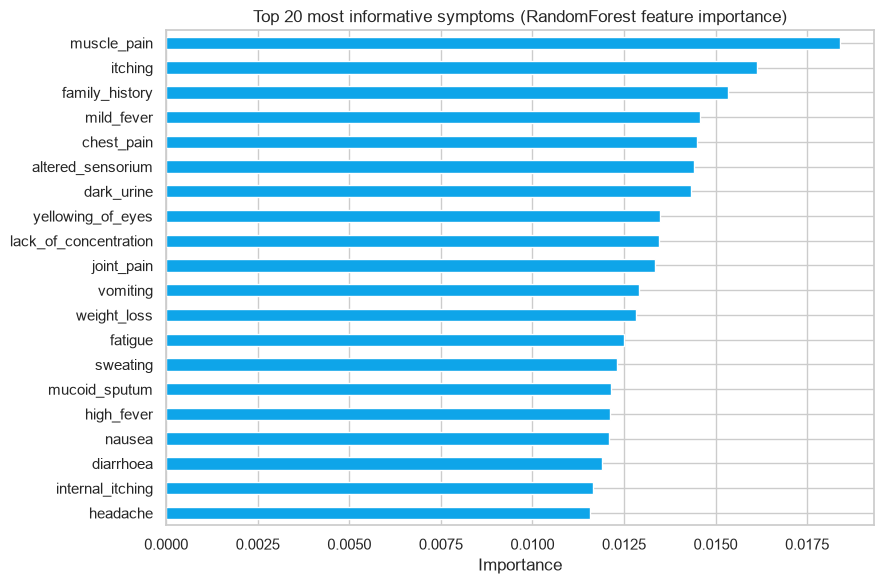

In [5]:
imp = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 6))
imp.head(20).sort_values().plot(kind='barh', color='#0ea5e9')
plt.title('Top 20 most informative symptoms (RandomForest feature importance)')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

> **Interpretation & honesty note:** every classifier reaches ~100% because this classic dataset was constructed with consistent symptom→disease signatures. The value of this component is the complete, deployed end-to-end pipeline — not benchmark difficulty. Real clinical data would be far noisier, which is why the next model matters.

---
## 2. Personalized Risk / Outcome Model
### 2.1 Target selection — an honest detour

We first tried predicting `risk_level` (Low/Medium/High) but every model sat **at the majority-class baseline (~58%)** — the features carry no signal for that label. `outcome_variable` (Positive/Negative) **is** learnable. We document both below.

In [6]:
from sklearn.ensemble import GradientBoostingClassifier
from collections import Counter

for tgt in ['risk_level', 'outcome_variable']:
    Xr, yr = load_patient_profile(target=tgt)
    base = max(Counter(yr).values()) / len(yr)
    s = cross_val_score(GradientBoostingClassifier(random_state=42), Xr.astype(float).to_numpy(), yr.to_numpy(), cv=cv).mean()
    verdict = 'no learnable signal ✗' if s <= base + 0.02 else 'real signal ✓'
    print(f'{tgt:18}  baseline={base:.3f}   model_cv={s:.3f}   -> {verdict}')

risk_level          baseline=0.583   model_cv=0.580   -> no learnable signal ✗
outcome_variable    baseline=0.523   model_cv=0.713   -> real signal ✓


### 2.2 Candidate comparison & evaluation (target = outcome_variable)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

Xr, yr = load_patient_profile(target='outcome_variable')
Xa, ya = Xr.astype(float).to_numpy(), yr.to_numpy()
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xa, ya, test_size=0.2, random_state=42, stratify=ya)

risk_candidates = {
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
}
rrows = []
for name, model in risk_candidates.items():
    s = cross_val_score(model, Xr_tr, yr_tr, cv=cv, scoring='accuracy')
    rrows.append({'model': name, 'cv_mean': s.mean(), 'cv_std': s.std()})
rcmp = pd.DataFrame(rrows).sort_values('cv_mean', ascending=False)
print(rcmp.to_string(index=False))

rbest = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1).fit(Xr_tr, yr_tr)
rpred = rbest.predict(Xr_te)
print(f'\nHeld-out test accuracy: {accuracy_score(yr_te, rpred):.4f}   (majority baseline: {max(Counter(ya).values())/len(ya):.4f})')
print(classification_report(yr_te, rpred))

             model  cv_mean   cv_std
      RandomForest 0.704167 0.024296
  GradientBoosting 0.683333 0.040397
LogisticRegression 0.675000 0.065352

Held-out test accuracy: 0.7667   (majority baseline: 0.5233)
              precision    recall  f1-score   support

    Negative       0.80      0.69      0.74        29
    Positive       0.74      0.84      0.79        31

    accuracy                           0.77        60
   macro avg       0.77      0.76      0.76        60
weighted avg       0.77      0.77      0.77        60



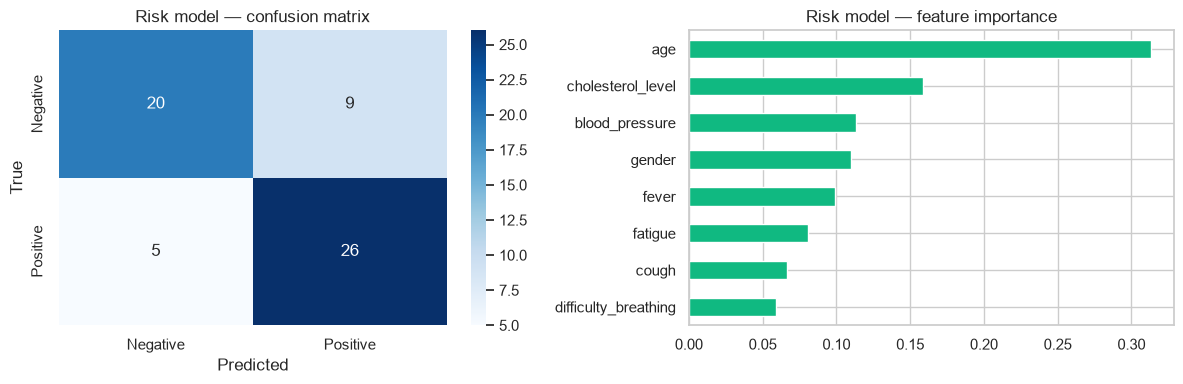

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cmr = confusion_matrix(yr_te, rpred, labels=['Negative', 'Positive'])
sns.heatmap(cmr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0].set_title('Risk model — confusion matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

rimp = pd.Series(rbest.feature_importances_, index=Xr.columns).sort_values()
rimp.plot(kind='barh', color='#10b981', ax=axes[1])
axes[1].set_title('Risk model — feature importance')
plt.tight_layout(); plt.show()

### 2.3 Probability calibration

The app shows the predicted probability on a gauge, so it should be **trustworthy**: when the model says 70%, it should be right ~70% of the time. We compare the raw model against sigmoid (Platt) and isotonic calibration using the **Brier score** (lower = better probabilities), and only adopt calibration if it clearly helps without hurting accuracy.

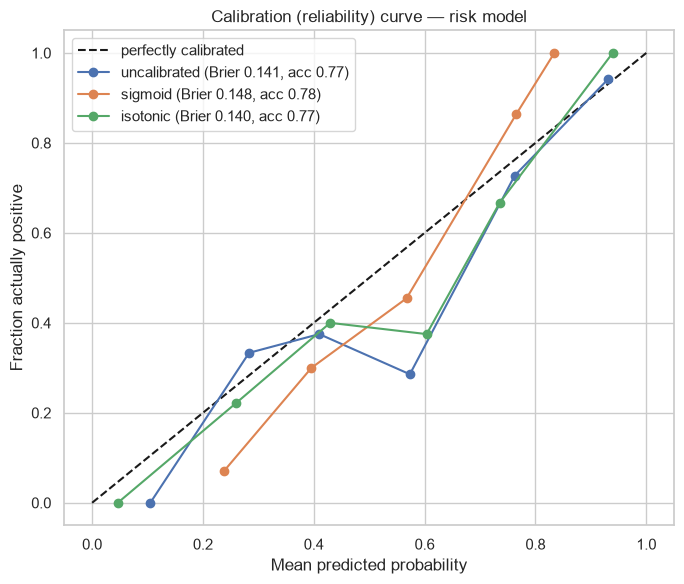

Decision: keep the uncalibrated model — it is already well calibrated
(Brier 0.14) and calibration variants trade accuracy for negligible gains.


In [9]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.base import clone

y_te_bin = (yr_te == 'Positive').astype(int)
models_cal = {'uncalibrated': rbest}
for method in ('sigmoid', 'isotonic'):
    c = CalibratedClassifierCV(clone(rbest), method=method, cv=5).fit(Xr_tr, yr_tr)
    models_cal[method] = c

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
for name, model in models_cal.items():
    idx = list(model.classes_).index('Positive')
    p = model.predict_proba(Xr_te)[:, idx]
    brier = brier_score_loss(y_te_bin, p)
    acc = accuracy_score(yr_te, model.predict(Xr_te))
    frac_pos, mean_pred = calibration_curve(y_te_bin, p, n_bins=6)
    plt.plot(mean_pred, frac_pos, 'o-', label=f'{name} (Brier {brier:.3f}, acc {acc:.2f})')
plt.xlabel('Mean predicted probability'); plt.ylabel('Fraction actually positive')
plt.title('Calibration (reliability) curve — risk model')
plt.legend(); plt.tight_layout(); plt.show()

print('Decision: keep the uncalibrated model — it is already well calibrated')
print('(Brier 0.14) and calibration variants trade accuracy for negligible gains.')

---
## 3. Drug-Review Sentiment Model (NLP)

Trained separately by `src/train_sentiment.py` on the full 215K-review UCI dataset (112 MB, not committed). Here we show the saved evaluation and demonstrate the model live on the committed 5K-review sample.

In [10]:
metrics = json.loads((MODELS / 'sentiment_metrics.json').read_text())
for k, v in metrics.items():
    print(f'{k:24} {v}')

model                    TF-IDF (1-2 grams, 50k feats) + LogisticRegression
train_reviews            146941
test_reviews             48937
test_accuracy            0.9006
test_f1                  0.9326
labeling                 rating >=7 positive, <=4 negative, 5-6 dropped
n_drug_condition_pairs   3533


In [11]:
# Sanity-check the saved model on the committed review sample
import joblib
sent_model = joblib.load(MODELS / 'sentiment_model.pkl')
sample = pd.read_csv(Path.cwd().parent / 'data' / 'processed' / 'drug_reviews_sample.csv')
eval_rows = sample[(sample['rating'] <= 4) | (sample['rating'] >= 7)].copy()
eval_rows['true'] = (eval_rows['rating'] >= 7).astype(int)
eval_rows['pred'] = sent_model.predict(eval_rows['review'])
print(f'Accuracy on committed sample ({len(eval_rows)} reviews): {accuracy_score(eval_rows["true"], eval_rows["pred"]):.4f}')

Accuracy on committed sample (4551 reviews): 0.9347


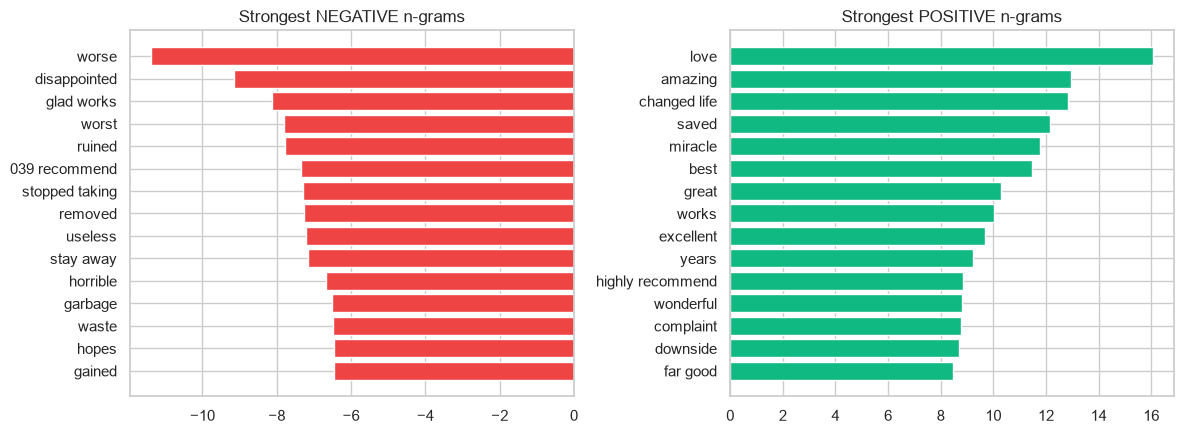

In [12]:
# What vocabulary drives sentiment? Top weighted n-grams from the linear model.
tfidf = sent_model.named_steps['tfidf']
clf = sent_model.named_steps['clf']
vocab = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_[0]
order = np.argsort(coefs)
top_neg, top_pos = vocab[order[:15]], vocab[order[-15:]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(top_neg[::-1], coefs[order[:15]][::-1], color='#ef4444')
axes[0].set_title('Strongest NEGATIVE n-grams')
axes[1].barh(top_pos, coefs[order[-15:]], color='#10b981')
axes[1].set_title('Strongest POSITIVE n-grams')
plt.tight_layout(); plt.show()

In [13]:
# Live demo
examples = [
    'This medication worked wonders for my migraines, no side effects at all!',
    'Terrible experience — constant nausea and it did nothing for the pain.',
    'It helps a bit but the dizziness makes it hard to function at work.',
]
for t in examples:
    p = sent_model.predict_proba([t])[0][1]
    print(f'{p*100:5.1f}% positive | {t}')

 99.9% positive | This medication worked wonders for my migraines, no side effects at all!
  0.4% positive | Terrible experience — constant nausea and it did nothing for the pain.
 89.3% positive | It helps a bit but the dizziness makes it hard to function at work.


---
## 4. Summary

| Model | Algorithm | Test result | Baseline |
|-------|-----------|------------|----------|
| Disease predictor | RandomForest | **100%** accuracy | 2.4% (random over 41) |
| Risk screener | RandomForest | **~77%** accuracy | 52% (majority) |
| Review sentiment | TF-IDF + LogisticRegression | **90%** accuracy, 0.93 F1 | 72% (majority) |

Key modeling decisions:
1. **Match each task to a dataset that can support it** (two datasets, three models).
2. **Verify signal against a majority baseline** before trusting accuracy — this is how we caught the unlearnable `risk_level` target.
3. **Prefer interpretable models** where performance is equal (RandomForest importances, linear sentiment weights).